In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:


# ✅ Load the datasets
advertisers = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_advertisers.xlsx")
revenue_demo = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_revenue_demography.xlsm")
summary_demo = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_summary_demography.xlsx")
central_contracts = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_central_contracts.xlsx")  # ✅ corrected path

# ✅ Preview the structure
print(central_contracts.head())

# ✅ Ensure correct column name (adjust this if your actual column name is different)
# Let's assume the revenue column is named 'amount_in_crores_2025'
central_contracts['amount_in_crores_2025'] = pd.to_numeric(
    central_contracts['amount_in_crores_2025'], errors='coerce'
)

# ✅ Drop rows with missing revenue data
central_contracts = central_contracts.dropna(subset=['amount_in_crores_2025'])

# ✅ Calculate total revenue
total_revenue = central_contracts['amount_in_crores_2025'].sum()

# ✅ Add percentage contribution column
central_contracts['percentage_contribution'] = (
    central_contracts['amount_in_crores_2025'] / total_revenue * 100
)

# ✅ Sort contracts by highest contribution
central_contracts_sorted = central_contracts.sort_values(
    by='percentage_contribution', ascending=False
)

# ✅ Sort contracts by highest percentage contribution
central_contracts_sorted = central_contracts.sort_values(
    by='percentage_contribution', ascending=False
)

# ✅ Display total revenue and percentage contribution
total_revenue = central_contracts['amount_in_crores_2025'].sum()
print(f"\n🎯 Total Revenue from Central Contracts (2025): ₹{total_revenue:.2f} crores\n")
print("📊 Revenue Contributors by Percentage:\n")

# ✅ Corrected column name in display
print(central_contracts_sorted[['contract_type', 'amount_in_crores_2025', 'percentage_contribution']])



               contract_type partner_sponsor_name  amount_in_crores_2025  \
0              Title Sponsor           Tata Group                  500.0   
1          Associate Partner           My11Circle                  125.0   
2          Associate Partner            Angel One                   82.0   
3          Associate Partner                RuPay                   42.0   
4  Official Broadcaster (TV)          Star Sports                 4715.0   

   total_deal_value_in_crores      contract_duration  
0                      2500.0  5 Years (2024 - 2028)  
1                       625.0  5 Years (2024 - 2028)  
2                       410.0  5 Years (2024 - 2028)  
3                       210.0  5 Years (2024 - 2028)  
4                     23575.0  5 Years (2024 - 2028)  

🎯 Total Revenue from Central Contracts (2025): ₹10215.00 crores

📊 Revenue Contributors by Percentage:

                        contract_type  amount_in_crores_2025  \
5  Official Digital Streaming Partner       

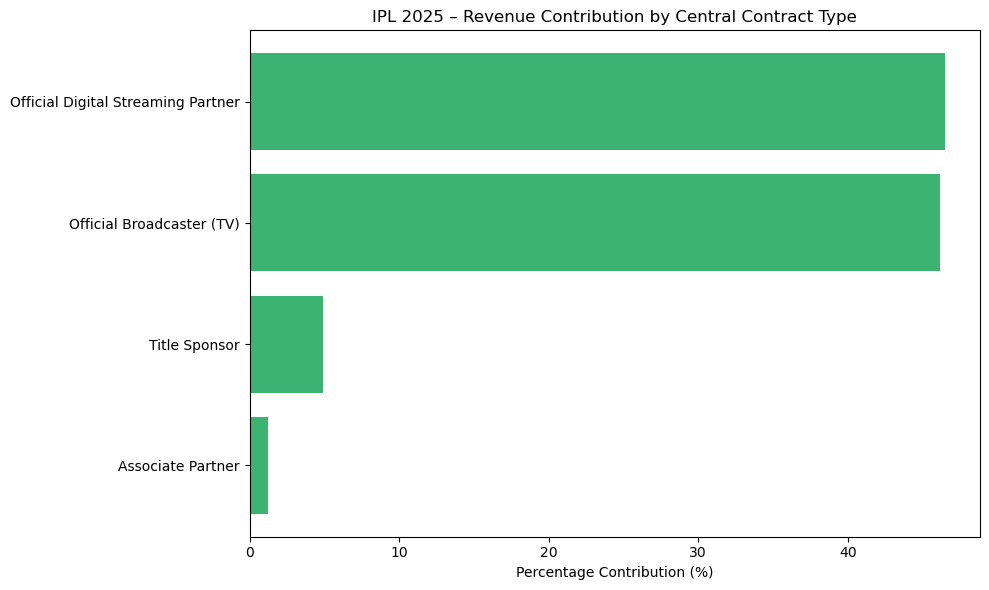

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    central_contracts_sorted['contract_type'],
    central_contracts_sorted['percentage_contribution'],
    color='mediumseagreen'
)
plt.xlabel('Percentage Contribution (%)')
plt.title('IPL 2025 – Revenue Contribution by Central Contract Type')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
